# Airbnb Analysis
The aim of this project is to predict AirBnB rental prices based on listed features using a Linear Regression model.

## 1. Load and Inspect Data

In [73]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Statistical Methods
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.metrics import (
    r2_score
)


# Models
from sklearn.linear_model import LinearRegression


In [49]:
df = pd.read_csv("data/airbnb_data.csv") # training data
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


The above data contains:
|column| details|
|-|-|
|id| Unique id for each row|
|name| Listing name|
|host_id| Unique host id|
|host_name| Host name|
|neighbourhood_group| Neighbourhood group name (e.g. Brooklyn, Queens, etc.)|
|neighbourhood| Specific neighbourhood|
|latitude| Location latitude|
|longitude| Location longitude|
|room_type| Type of room available (e.g. Private room, entire home, etc.)|
|price| Daily room price|
|minimum_nights| Minimum number of nights for stay|
|number_of_reviews| Number of reviews for listing|
|reviews_per_month| Number of reviews per month|
|calculated_host_listing_count| Number of listings for given host|
|availability_365| Number of days per year listing is available|


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27379 entries, 0 to 27378
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27379 non-null  int64  
 1   name                            27370 non-null  str    
 2   host_id                         27379 non-null  int64  
 3   host_name                       27369 non-null  str    
 4   neighbourhood_group             27379 non-null  str    
 5   neighbourhood                   27379 non-null  str    
 6   latitude                        27379 non-null  float64
 7   longitude                       27379 non-null  float64
 8   room_type                       27379 non-null  str    
 9   price                           27379 non-null  int64  
 10  minimum_nights                  27379 non-null  int64  
 11  number_of_reviews               27379 non-null  int64  
 12  last_review                     21746 non-n

Note: since we are utilizing regression, we will need to drop non-numeric values.

Further, some of the numeric columns are not useful (i.e. id).

Let's make a list of useful columns so we can look into them further in this initial stage:

In [51]:
cols = ["latitude",
        "longitude",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365"]
df[cols].describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,27379.000000,27379.000000,27379.000000,27379.000000,27379.000000,21746.000000,27379.000000,27379.000000
mean,40.728836,-73.952071,151.569561,7.056722,23.228131,1.383797,7.228788,113.430293
std,0.054629,0.046278,219.807784,20.194945,44.281418,1.714116,33.173634,132.039807
min,40.506410,-74.242850,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.689955,-73.983080,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723030,-73.955700,105.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763045,-73.935830,175.000000,5.000000,23.000000,2.030000,2.000000,230.000000
max,40.913060,-73.717950,10000.000000,999.000000,607.000000,58.500000,327.000000,365.000000


Some quick observations on the above:
- **price** has a maximum of 10000, with a mean of 151 and std of 219, meaning there are likely outliers
- **minimum_nights** has a maximum value of 10,000 which seems wrong and is definitely an outlier
- **availability_365** has a maximum of 365, which suggests that my assumption that this represents the number of days a year the listing is available is likely to be correct 

### Missing Data

In [52]:
print(df[cols].isnull().sum())
print()
print(100 * df[cols].isnull().sum() / df[cols].count())

latitude                             0
longitude                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
reviews_per_month                 5633
calculated_host_listings_count       0
availability_365                     0
dtype: int64

latitude                           0.000000
longitude                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
reviews_per_month                 25.903614
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64


Only ```reviews_per_month``` has missing values (missing ~26%). This is quite a lot, and I would be surprised if this particular column was useful for our analysis. 

Let's have a bit of a closer look at this:

In [53]:
df[df["reviews_per_month"].isnull()].head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10,11,NEW SUNNY PEACEFUL ROOM in Prime Williamsburg,8119817,Mila,Brooklyn,Williamsburg,40.71821,-73.94116,Private room,115,2,0,NaN,NaN,2,121
17,18,*NO GUEST SERVICE FEE* Beekman Tower One Bedro...,205031545,Red Awning,Manhattan,Midtown,40.75403,-73.96714,Entire home/apt,714,28,0,NaN,NaN,49,250
27,28,SOUTH SLOPE Brooklyn - Bright and Spacious Bed...,7007654,Dhwani,Brooklyn,Sunset Park,40.65976,-73.99191,Private room,35,2,0,NaN,NaN,1,0
32,33,Small Comfy space,104028121,Diana,Manhattan,Washington Heights,40.85044,-73.93042,Private room,41,1,0,NaN,NaN,1,38
46,47,"Wonderful 3 people room near M,J, L,G trains",248161322,Sergii,Brooklyn,Bushwick,40.70028,-73.93952,Shared room,35,30,0,NaN,NaN,14,333


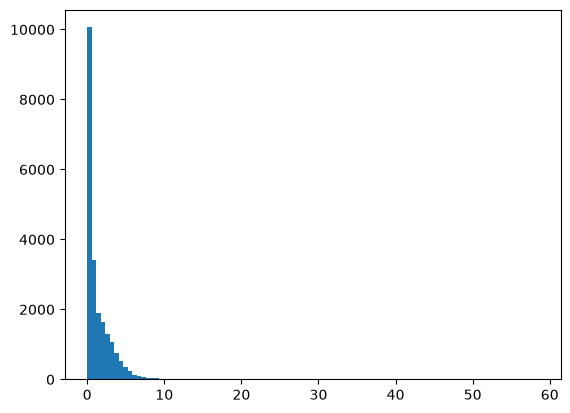

In [54]:
plt.hist(df["reviews_per_month"], bins=100)
plt.show()

Upon further inspection, we note that the minimum number of reviews per month is 0.01. Additionally, the distribution of reviews is extremely right-skewed. It is possible that ```reviews_per_month``` defaults to NaN when no reviews are listed. If this assumption is correct, that means that we can impute all NaN's in this column as 0. This is unlikely to greatly affect our data, as it is extremely right-skewed regardless (as shown in the histogram above).

## 2. Data Preparation

As there is not much preparation involved, we do it first before inspecting the distributions in detail.

## 2.1 Label Encoding

It is likely that room type, neighbourhood, and neighbourhood_group will be correlated with price. Here we encode these into numerical values.

In [55]:
label_encoder = LabelEncoder()

df["room_type"] = label_encoder.fit_transform(df["room_type"])
df["neighbourhood"] = label_encoder.fit_transform(df["neighbourhood"])
df["neighbourhood_group"] = label_encoder.fit_transform(df["neighbourhood_group"])

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,1,40,40.69591,-73.96284,1,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,1,79,40.68769,-73.97490,1,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,1,50,40.67667,-73.91750,0,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,3,214,40.74340,-73.90588,0,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,1,178,40.66600,-73.99020,0,210,4,88,7/4/2019,4.41,1,20


### 2.2 Drop Columns

In [56]:
cols = ["latitude",
        "longitude",
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "room_type",
        "neighbourhood",
        "neighbourhood_group"]

df = df[cols]
df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type,neighbourhood,neighbourhood_group
0,40.69591,-73.96284,58,2,1,0.10,1,0,1,40,1
1,40.68769,-73.97490,99,5,4,0.17,1,250,1,79,1
2,40.67667,-73.91750,180,2,126,3.74,1,74,0,50,1
3,40.74340,-73.90588,50,1,95,5.63,2,0,0,214,3
4,40.66600,-73.99020,210,4,88,4.41,1,20,0,178,1


### 2.3 Impute Data (reviews_per_month)

In [57]:
df["reviews_per_month"]= df["reviews_per_month"].fillna(0)
print(df[cols].isnull().sum())


latitude                          0
longitude                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
room_type                         0
neighbourhood                     0
neighbourhood_group               0
dtype: int64


### 2.4 Train/Test Split

In [58]:
X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

All clean and ready to Linearly Regress!

## 3. Exploratory Analysis

Here, we see if we can learn anything about the data by inspecting:
- Univariate distributions
- Bivariate distributions
- Correlations

### 3.1 Univariate Analysis

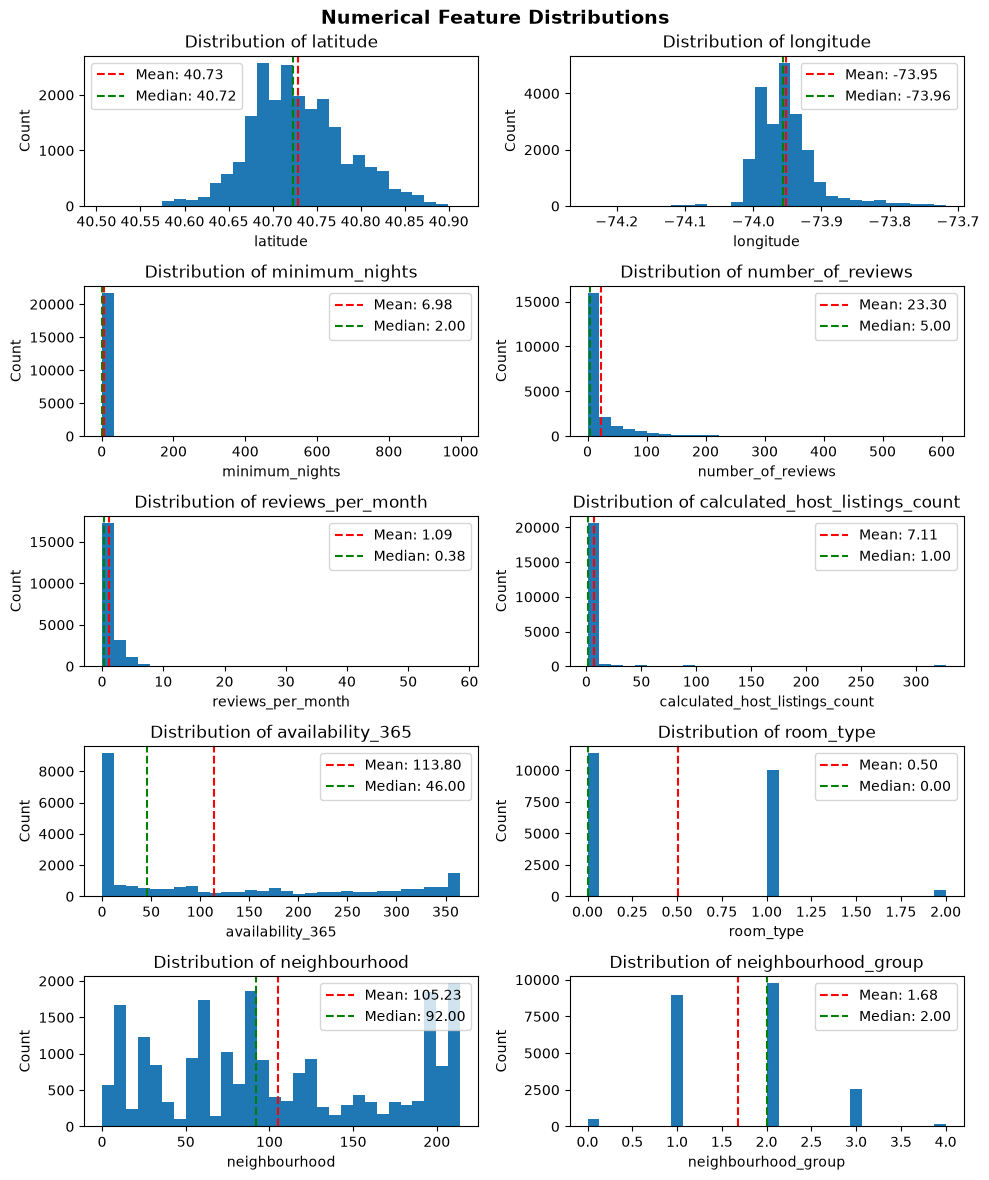

In [61]:
X_cols = ["latitude",
        "longitude",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "room_type",
        "neighbourhood",
        "neighbourhood_group"]

fig, axes = plt.subplots(
    5, 2,
    figsize=(10, 12),
    squeeze=False
)

axes = axes.flatten()
for idx, col in enumerate(X_cols):
    axes[idx].hist(X_train[col].dropna(), bins=30)
    axes[idx].axvline(X_train[col].mean(), color="red", linestyle="--", label=f"Mean: {X_train[col].mean():.2f}")
    axes[idx].axvline(X_train[col].median(), color="green", linestyle="--", label=f"Median: {X_train[col].median():.2f}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Count")
    axes[idx].legend()
    axes[idx].set_title(f"Distribution of {col}")




plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

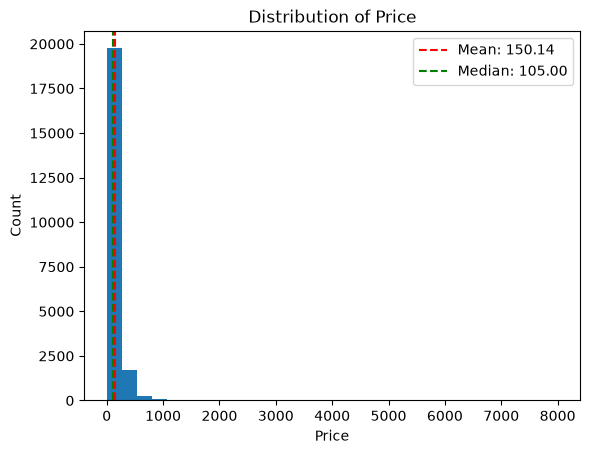

In [64]:
# Target Variable (price)
plt.hist(y_train.dropna(), bins=30)
plt.axvline(y_train.mean(), color="red", linestyle="--", label=f"Mean: {y_train.mean():.2f}")
plt.axvline(y_train.median(), color="green", linestyle="--", label=f"Median: {y_train.median():.2f}")
plt.xlabel("Price")
plt.ylabel("Count")
plt.legend()
plt.title(f"Distribution of Price")
plt.show()

**Observations:**
- longitude and latitude are approximately normally distributed
- All other distributions look right-skewed
- There are significant outliers in
    - minimum_nights
    - number_of_reviews
    - reviews_per_month
    - calculated_host_listings_count
    - price

Let's look at this list of outliers in more detail

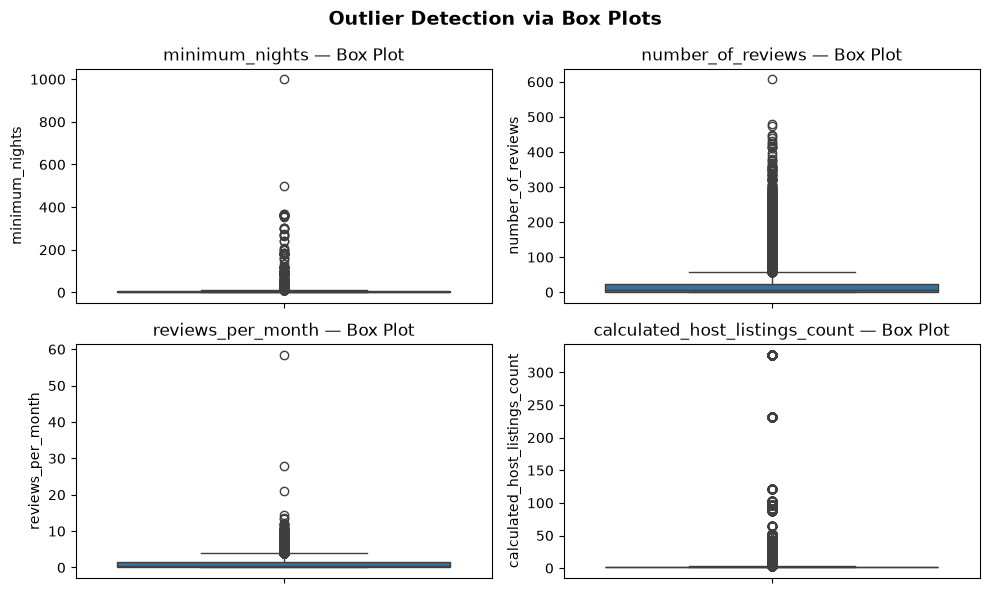

In [17]:
X_cols = ["minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count"]

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 6),
    squeeze=False
)

axes = axes.flatten()
for idx, col in enumerate(X_cols):
    sns.boxplot(X_train[col], ax=axes[idx])
    axes[idx].set_title(f"{col} — Box Plot")



plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations:**
- minimum_nights looks like it has only a few outliers, and a heavily skewed distribution
- reviews_per_month may have one outlier, but may also be just heavily skewed
- both number_of_reviews and calculated_host_listing_count look like they don't have legitimate outliers

Let's now look at **price**:

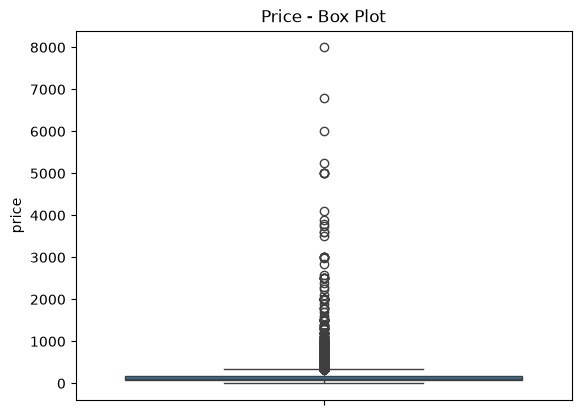

In [28]:
# Target Variable (price)
sns.boxplot(y_train)
plt.title("Price - Box Plot")
plt.show()

There *may* be outliers in the above, but it is hard to say definitively.

### 3.2 Bivariate Analysis (Target: Price)

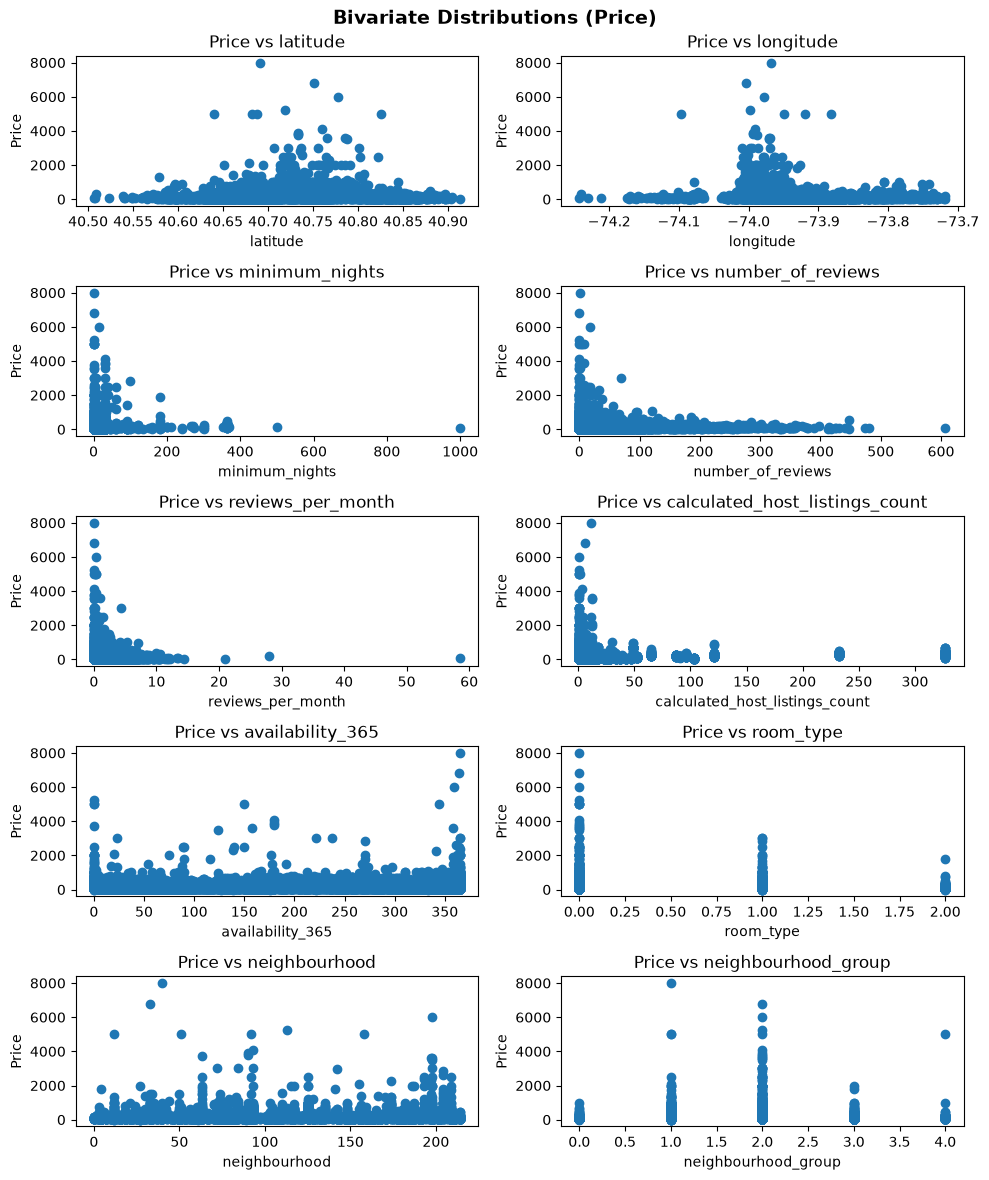

In [65]:
X_cols = ["latitude",
        "longitude",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "room_type",
        "neighbourhood",
        "neighbourhood_group"]

fig, axes = plt.subplots(
    5, 2,
    figsize=(10, 12),
    squeeze=False
)

axes = axes.flatten()
for idx, col in enumerate(X_cols):
    axes[idx].scatter(X_train[col], y_train)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Price")
    axes[idx].set_title(f"Price vs {col}")



plt.suptitle("Bivariate Distributions (Price)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

From the above, it is possible that we can use a logarithmic transform on the following features to enhance our fit:
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count

### 3.3 Correlations

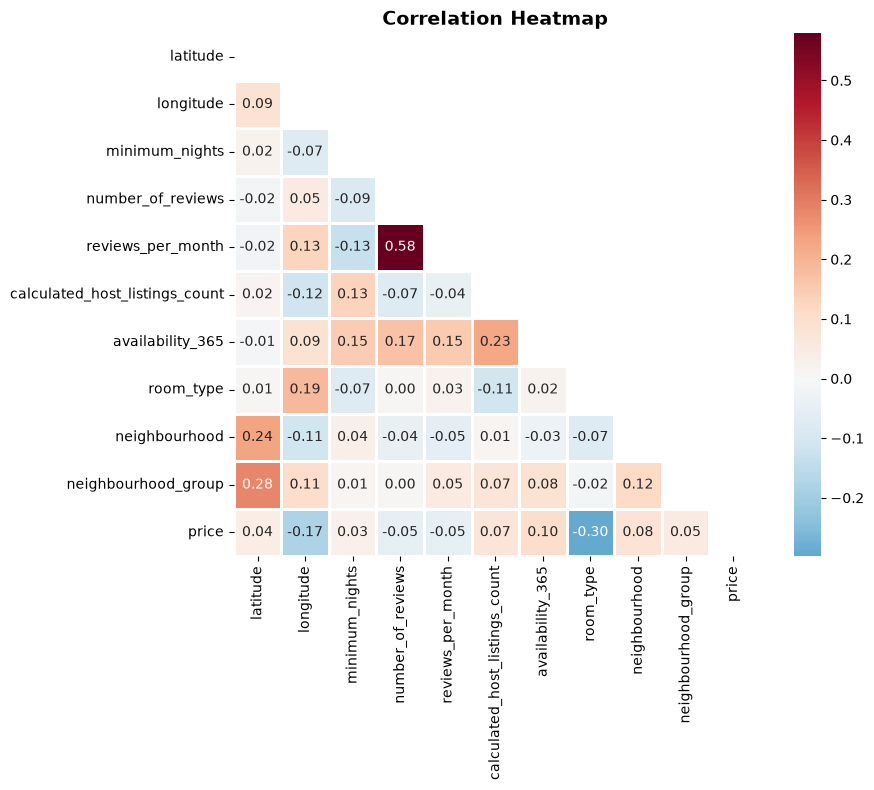

In [66]:
# First pick out our columns (these can be numeric or categorical)
num_cols = ["latitude",
        "longitude",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
        "room_type",
        "neighbourhood",
        "neighbourhood_group"]

numeric_df = X_train[num_cols].copy()

numeric_df["price"] = y_train

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

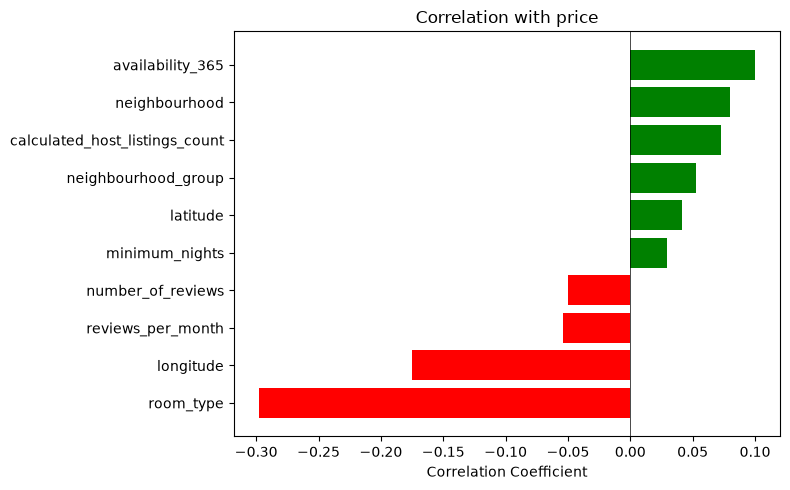

In [67]:
target_var = "price"


# Correlation with target
target_corr = corr[target_var].drop(target_var).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["red" if v < 0 else "green" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {target_var}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

### 3.4 Test Logarithmic Transform

I want to check whether transforming the data enhances the correlations.

As a reminder, the columsn I want to check are:
- minimum_nights
- number_of_reviews
- reviews_per_month
- calculated_host_listings_count

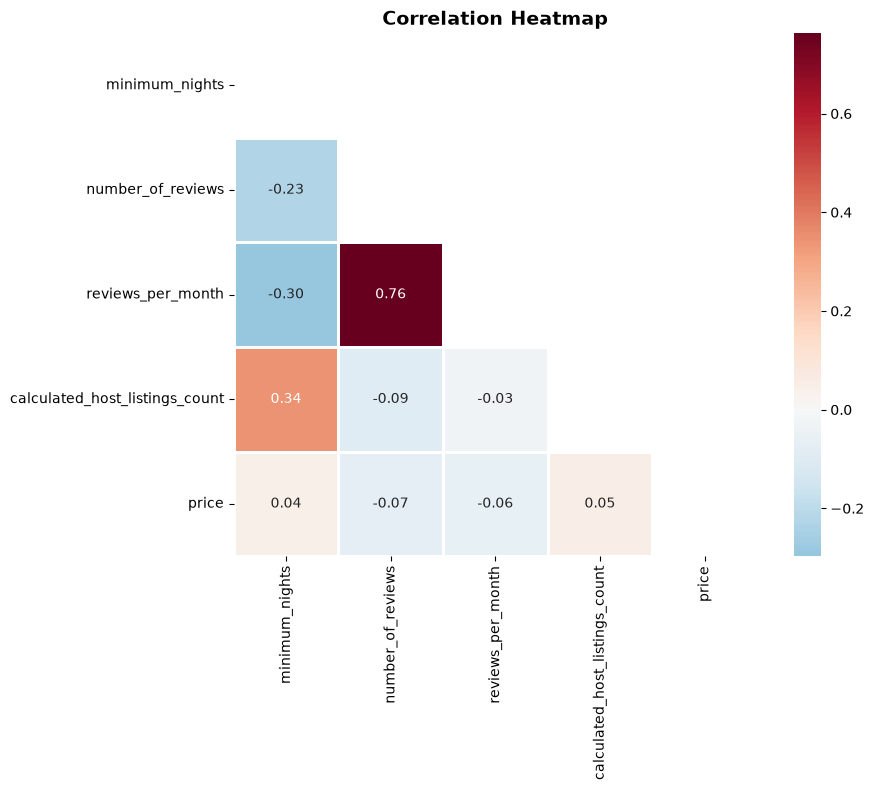

In [68]:
# First pick out our columns (these can be numeric or categorical)
num_cols = ["minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count"]
log_df = X_train[num_cols].copy()


for col in num_cols:
    log_df[col] = np.log1p(log_df[col])




log_df["price"] = y_train

corr = log_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

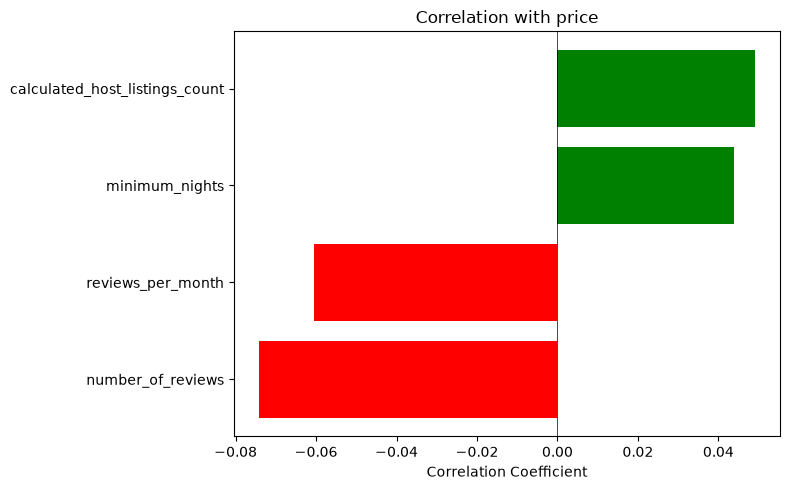

In [69]:
target_var = "price"


# Correlation with target
target_corr = corr[target_var].drop(target_var).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["red" if v < 0 else "green" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {target_var}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

Didn't change the correlations much, probably a sign to not rely on this.

## 4. Model the Data

In [76]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
print('R2 score:', r2_score(y_test, y_pred))


R2 score: 0.07139179707205123
accuracy: 0.07139179707205123
